In [13]:
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier

In [14]:
df = pd.read_csv('../data/Titanic_processed.csv')
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [15]:
features = df.drop(columns=['Survived'])
labels = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, min_samples_split=10)

# n_estimators = No of indiviual decision trees used by model for pattern recognition.. 

# max_depth and min_samples_split are added to stop the trees from growing too deep and prevent overfitting since the dataset is 
# small and random forest is a complex algorithm as compared to logistic regression

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
predictions = rf_model.predict(X_test)

In [18]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

c_matrix = confusion_matrix(y_test, predictions)
print(c_matrix, end = '\n\n')

accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy * 100: .2f}%', end = '\n\n')

print(predictions)

[[154  13]
 [ 35  65]]

Accuracy:  82.02%

[0 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0
 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0 1
 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1
 1 1 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0]


In [19]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.81      0.92      0.87       167
           1       0.83      0.65      0.73       100

    accuracy                           0.82       267
   macro avg       0.82      0.79      0.80       267
weighted avg       0.82      0.82      0.81       267



In [20]:
# Finding out which feature is given the most importance-- 

feature_imp = pd.Series(rf_model.feature_importances_, index= X_train.columns)
print(feature_imp.sort_values(ascending= False))

male      0.437476
Fare      0.176762
Pclass    0.129599
Age       0.120030
SibSp     0.058409
Parch     0.039665
S         0.027820
Q         0.010238
dtype: float64


In [21]:
# Gender -- was given the highest importance while training, while the embarked feature had the least importance

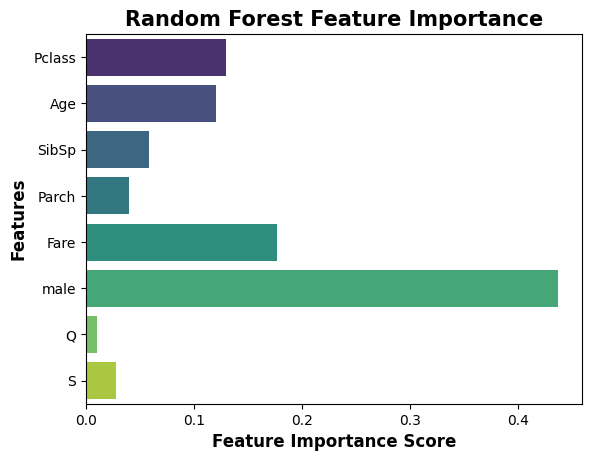

In [22]:
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.barplot(x= feature_imp, y = feature_imp.index, hue = feature_imp.index, palette= 'viridis', legend= False)
plt.xlabel('Feature Importance Score', fontsize= 12, fontweight= 'bold')
plt.ylabel('Features', fontsize= 12, fontweight= 'bold')
plt.title('Random Forest Feature Importance', fontsize= 15, fontweight= 'bold')

plt.show()
